# Imports

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
import rasterio
import wandb
import keras_tuner as kt


from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Load SAR Images

In [2]:
import tensorflow as tf
import rasterio
import numpy as np

def load_sar_tiff_tf(path):
    def _read(p):
        with rasterio.open(p.decode()) as src:
            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)

        # Fixed-range normalization
        vv = np.clip(vv, -35.0, 5.0)
        vh = np.clip(vh, -40.0, 0.0)

        vv = (vv + 35.0) / 40.0
        vh = (vh + 40.0) / 40.0

        ratio = vv / (vh + 1e-6)
        
        img = np.stack([vv, vh], axis=-1)

        # 🔑 RESIZE 2048 → 512
        img = tf.image.resize(img, (512, 512), method="bilinear").numpy()

        return img

    img = tf.numpy_function(_read, [path], tf.float32)
    img.set_shape([512, 512, 2])
    return img

# Wandb Config

In [3]:
wandb.init(
    project="CNN_Oil_Classification",
    name="CNN-6Conv-32Filters-512x512",
    config={
        "input_shape": (512, 512, 2),
        "conv_layers": 6,
        "filters": 32,
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": [20, 20],
        "activation": "relu",
        "optimizer": "Adam",
        "loss": "binary_crossentropy",
        "epochs": 50,
        "batch_size": 8
    }
)

wandb: Currently logged in as: paras-ningune01 (paras-ningune01-pvg-coet) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Dataset Preparation

In [4]:
import os

DATASET_ROOT = "/Volumes/Windows8_OS/Dataset/Dataset-OG/Test"
IMAGES_ROOT = os.path.join(DATASET_ROOT, "Images")

OIL_DIR = os.path.join(IMAGES_ROOT, "Oil")
NO_OIL_DIR = os.path.join(IMAGES_ROOT, "No_Oil")

oil_files = [os.path.join(OIL_DIR, f) for f in os.listdir(OIL_DIR) if f.endswith(".tif")]
no_oil_files = [os.path.join(NO_OIL_DIR, f) for f in os.listdir(NO_OIL_DIR) if f.endswith(".tif")]

print("Oil images:", len(oil_files))
print("No-Oil images:", len(no_oil_files))

Oil images: 150
No-Oil images: 150


In [5]:
def make_dataset(paths, label, batch_size=8):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(lambda x: (load_sar_tiff_tf(x), label),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds

In [6]:
oil_ds = make_dataset(oil_files, 1)
no_oil_ds = make_dataset(no_oil_files, 0)

dataset = oil_ds.concatenate(no_oil_ds)

total_samples = len(oil_files) + len(no_oil_files)

dataset = dataset.shuffle(
    buffer_size=total_samples,
    reshuffle_each_iteration=False
)

dataset = dataset.cache()
dataset = dataset.prefetch(tf.data.AUTOTUNE)

options = tf.data.Options()
options.experimental_deterministic = False
dataset = dataset.with_options(options)

I0000 00:00:1768721545.058717 4341016 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1768721545.058955 4341016 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [7]:
num_oil = len(oil_files)
num_no_oil = len(no_oil_files)

total_samples = num_oil + num_no_oil
print("Total samples:", total_samples)

Total samples: 300


In [8]:
dataset = dataset.shuffle(
    buffer_size=total_samples,
    reshuffle_each_iteration=False
)

In [9]:
train_size = int(0.8 * total_samples)
test_size  = total_samples - train_size

print("Train samples:", train_size)
print("Test samples:", test_size)

Train samples: 240
Test samples: 60


In [10]:
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, tf.random.uniform([], 0, 4, tf.int32))

    # Mild speckle-like noise
    noise = tf.random.normal(tf.shape(image), stddev=0.02)
    image = tf.clip_by_value(image + noise, 0.0, 1.0)

    return image, label

In [11]:
BATCH_SIZE = 8

train_ds = dataset.take(train_size)
test_ds  = dataset.skip(train_size)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = train_ds.map(
    augment,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds  = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Model Architecture

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_detection_cnn(hp):
    model = Sequential()

    # Hyperparameter: number of conv blocks
    num_blocks = hp.Int("num_conv_blocks", min_value=3, max_value=8)

    for i in range(num_blocks):
        filters = hp.Choice(f"filters_{i}", [16, 32, 64])

        if i == 0:
            model.add(Conv2D(
                filters,
                (3, 3),
                activation="relu",
                padding="same",
                input_shape=(512, 512, 2)
            ))
        else:
            model.add(Conv2D(
                filters,
                (3, 3),
                activation="relu",
                padding="same"
            ))

        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    # Hyperparameter: dense units
    dense_units = hp.Choice("dense_units", [16, 32, 64])
    model.add(Dense(dense_units, activation="relu"))

    # Hyperparameter: dropout
    model.add(Dropout(
        hp.Float("dropout", min_value=0.2, max_value=0.5, step=0.1)
    ))

    model.add(Dense(1, activation="sigmoid"))

    # Hyperparameter: learning rate
    lr = hp.Choice("learning_rate", [1e-3, 1e-4, 3e-5])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model


# Tuner Config

In [26]:
tuner = kt.RandomSearch(
    build_detection_cnn,
    objective="val_accuracy",
    max_trials=15,
    executions_per_trial=1,
    directory="CNN_Oil_Classification",
    project_name="classification"
)


In [28]:
tuner.search(
    train_ds,
    validation_data=test_ds,
    epochs=50
)

Trial 15 Complete [00h 07m 01s]
val_accuracy: 0.8333333134651184

Best val_accuracy So Far: 0.9333333373069763
Total elapsed time: 02h 08m 27s


# Best Parameters

In [29]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best conv blocks:", best_hp.get("num_conv_blocks"))
print("Best dense units:", best_hp.get("dense_units"))
print("Best dropout:", best_hp.get("dropout"))
print("Best learning rate:", best_hp.get("learning_rate"))

Best conv blocks: 7
Best dense units: 16
Best dropout: 0.2
Best learning rate: 0.0001


In [30]:
best_model = tuner.get_best_models(1)[0]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [33]:
callbacks = [
    EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
    ),
    
    tf.keras.callbacks.ModelCheckpoint(
        filepath="CNN_checkpoints/model_epoch_{epoch}.weights.h5",
        save_weights_only=True,
        save_best_only=False
    )
]

# Best Model Fitting

In [34]:
history = best_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=[callbacks, WandbMetricsLogger(log_freq="epoch")]
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 213ms/step - accuracy: 0.8888 - loss: 0.2776 - val_accuracy: 0.9333 - val_loss: 0.2957
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.9220 - loss: 0.2660 - val_accuracy: 0.9000 - val_loss: 0.3105
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - accuracy: 0.9108 - loss: 0.2476 - val_accuracy: 0.9333 - val_loss: 0.2802
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - accuracy: 0.9260 - loss: 0.2492 - val_accuracy: 0.9167 - val_loss: 0.2829
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 205ms/step - accuracy: 0.9146 - loss: 0.2332 - val_accuracy: 0.9167 - val_loss: 0.2679
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - accuracy: 0.9114 - loss: 0.2333 - val_accuracy: 0.9167 - val_loss: 0.2637
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - accuracy: 0.8914 - loss: 0.2205 - val_accuracy: 0.9167 - val_loss: 0.2493
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.9342 - loss: 0.2115 - val_accuracy: 0

# Metrics

In [35]:
train_loss, train_acc = best_model.evaluate(train_ds)
print(f"Training Accuracy: {train_acc * 100:.2f}%")

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9699 - loss: 0.0714
Training Accuracy: 97.50%


In [36]:
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Testing Accuracy: {test_acc * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9777 - loss: 0.0721
Testing Accuracy: 96.67%


In [37]:
print("===================================")
print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Test  Accuracy: {test_acc * 100:.2f}%")
print("===================================")

Train Accuracy: 97.50%
Test  Accuracy: 96.67%


In [45]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    preds = best_model.predict(x_batch, verbose=0)
    preds = (preds > 0.5).astype(int)

    y_true.extend(y_batch.numpy())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [46]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[30  0]
 [ 2 28]]


In [47]:
def plot_confusion_matrix(cm, class_names, normalize=False):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, f"{cm[i, j]:.2f}" if normalize else cm[i, j],
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()


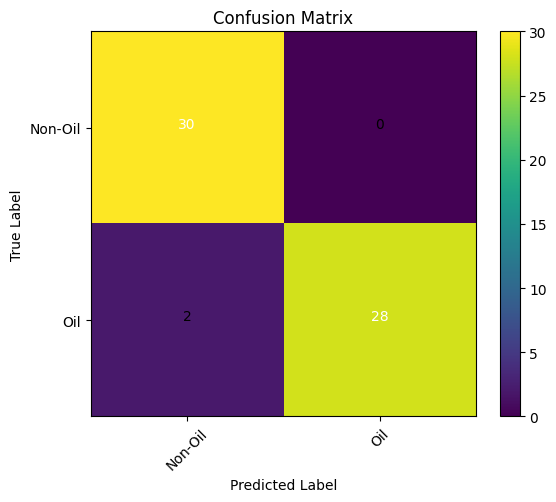

In [48]:
plot_confusion_matrix(
    cm,
    class_names=["Non-Oil", "Oil"],
    normalize=False
)


# Plots

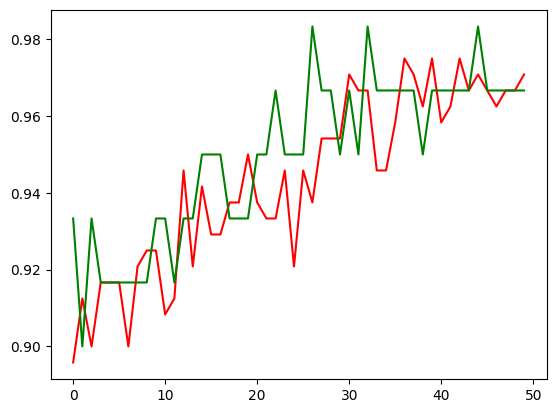

In [38]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color="red")
plt.plot(history.history['val_accuracy'], color="green")
plt.show()

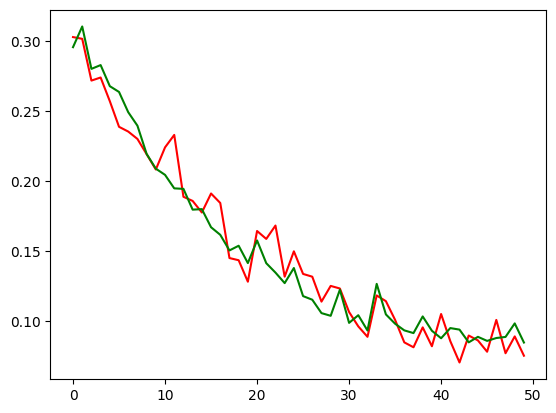

In [39]:
plt.plot(history.history['loss'], color="red")
plt.plot(history.history['val_loss'], color="green")
plt.show()

# Plot Images with actual and predicted results

In [83]:
import numpy as np
import matplotlib.pyplot as plt

def plot_random_combined_sar(model, test_ds, class_names, n=15, max_batches=30):
    images, labels = [], []

    for batch_x, batch_y in test_ds.take(max_batches):
        images.append(batch_x.numpy())
        labels.append(batch_y.numpy())

    images = np.concatenate(images, axis=0)
    labels = np.concatenate(labels, axis=0)

    idxs = np.random.choice(len(images), size=n, replace=False)

    preds = model.predict(images[idxs], verbose=0)

    if preds.shape[-1] == 1:
        y_pred = (preds > 0.5).astype(int).flatten()
        confidences = preds.flatten()
    else:
        y_pred = np.argmax(preds, axis=1)
        confidences = np.max(preds, axis=1)

    if len(labels.shape) > 1:
        y_true = np.argmax(labels[idxs], axis=1)
    else:
        y_true = labels[idxs]

    plt.figure(figsize=(12, 20))

    for i, idx in enumerate(idxs):
        oil_img = images[idx]
        combined = 0.3*oil_img[..., 0] + 0.7*oil_img[..., 1]

        plt.subplot(5, 3, i + 1)
        plt.imshow(combined, cmap="gray")
        plt.axis("off")

        true_label = class_names[y_true[i]]
        pred_label = class_names[y_pred[i]]

        color = "green" if y_true[i] == y_pred[i] else "red"

        plt.title(
            f"T: {true_label} | P: {pred_label} ({confidences[i]:.2f})",
            color=color,
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

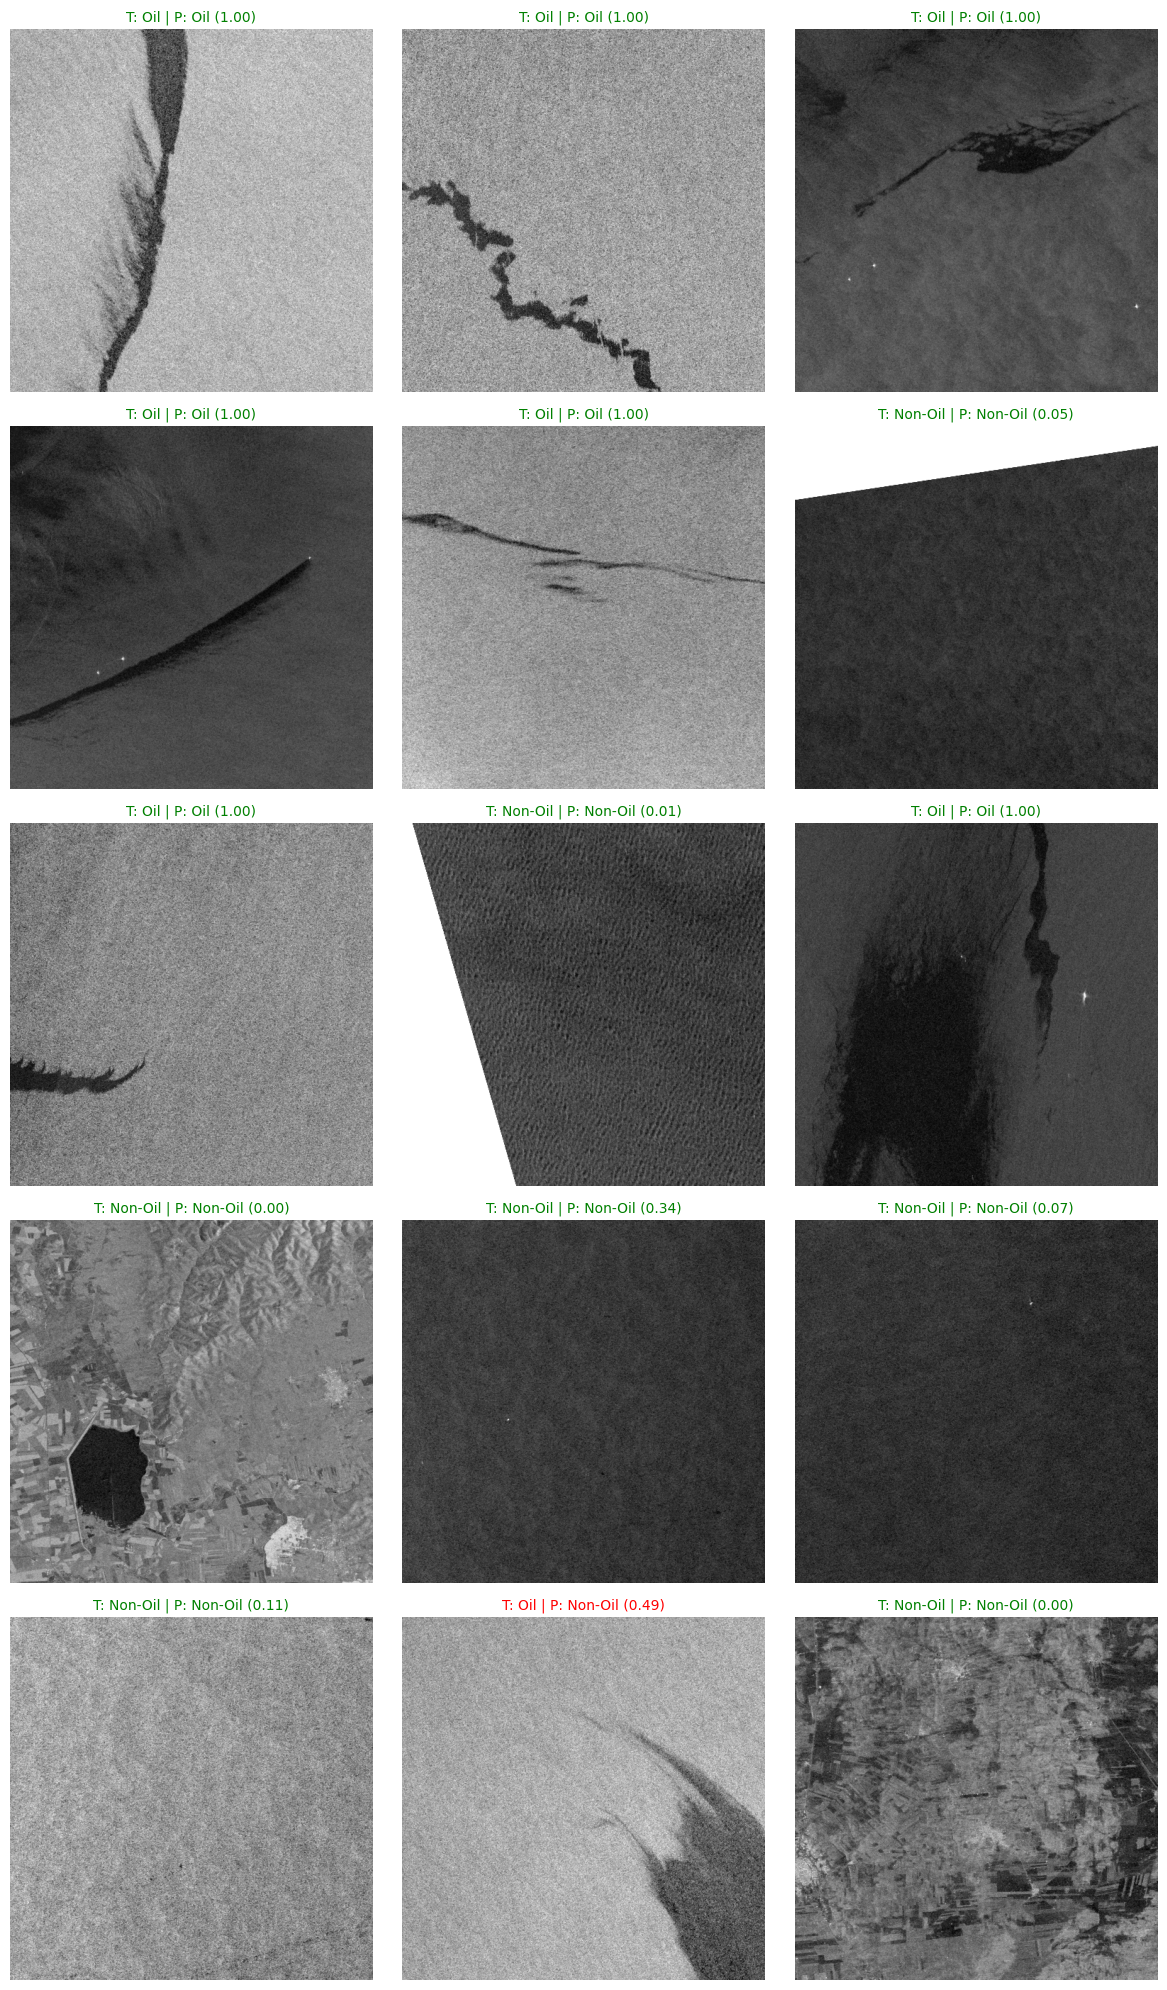

In [84]:
class_names = ["Non-Oil", "Oil"]

plot_random_combined_sar(
    best_model,
    test_ds,
    class_names,
    n=15
)

# Save Model

In [43]:
best_model.export("./CNN_checkpoints/Model/model")

INFO:tensorflow:Assets written to: ./CNN_checkpoints/Model/model/assets


INFO:tensorflow:Assets written to: ./CNN_checkpoints/Model/model/assets


Saved artifact at './CNN_checkpoints/Model/model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  14435221584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16051198800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16051196112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16051197648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16051195920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16051198224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16051196688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16051198608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16051198416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16051192656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16051198032: TensorSpec(shape=(), dtype=t